# Mod C - Week 5 | Support Vector Machines 

Use Support Vector Machines (SVM) on the Capstone datasets to build and evaluate classification models. The process will include scaling the features for better performance, training SVM models with different kernels (linear, polynomial, and RBF), and measuring results with metrics like accuracy, precision, recall, F1-score, confusion matrix, and ROC-AUC.And also tune key parameters, such as C and gamma, to find the right balance between margin size and classification accuracy.

# Capstone Project: Cybersecurity - Network Threat Detection using Anomaly detection and attack classification
The three datasets under use are 
1. BETH dataset – Contains network traffic records labeled for different attack types, focusing on distinguishing benign vs. malicious activities.
2. Cybersecurity Attacks dataset – Provides additional records of real-world attack behaviors, enabling comparison and model generalization across datasets.
3. UNSW-NB15 dataset – A widely used benchmark dataset for network intrusion detection, including features such as packet statistics, byte counts, and flow information, with multiple classes of cyberattacks.

#### Imports and Load datasets from kaggle

In [2]:
## General libraries 
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import os
import sys 

### Libraries for train test split and models

from sklearn.preprocessing import LabelEncoder
from datetime import datetime, timedelta
from sklearn.model_selection import train_test_split
from sklearn.metrics import root_mean_squared_error
from sklearn.metrics import mean_absolute_error,ConfusionMatrixDisplay, confusion_matrix, accuracy_score, f1_score

  
#########  Linraies for Logistic Regression regression
 
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import f1_score, mean_squared_error

random_state = 0

#####################  Libraries for SVM #####################
from sklearn.svm import OneClassSVM, SVC,LinearSVC
from sklearn.ensemble import IsolationForest
from sklearn.model_selection import GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    roc_auc_score, roc_curve, accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)
from sklearn.metrics import roc_curve, auc


# week 6 decision trees and random forest 
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Optional: make plots nicer
%matplotlib inline
sns.set(style="whitegrid")

## LOAD DATASETS and specific libraries
 
import kagglehub
import os

# DATASET 1 :  BETH cyberseurity dataset
beth_dataset_path = kagglehub.dataset_download("katehighnam/beth-dataset")
print("Path to dataset files:", beth_dataset_path)
print(os.listdir(beth_dataset_path))
kernel_files = [
    "labelled_training_data.csv",
    "labelled_validation_data.csv",
    "labelled_testing_data.csv"
]
dataframes = [pd.read_csv(os.path.join(beth_dataset_path, file)) for file in kernel_files]
df_beth_merged = pd.concat(dataframes, ignore_index=True)


# DATASET 2: Cybersecurity Dataset
CSA_dataset_path = kagglehub.dataset_download("teamincribo/cyber-security-attacks")
print("Path to dataset files:", CSA_dataset_path)
print(os.listdir(CSA_dataset_path))
csa_csv_path = os.path.join(CSA_dataset_path, "cybersecurity_attacks.csv")
df_csa = pd.read_csv(csa_csv_path)


# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))


c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\katehighnam\beth-dataset\versions\3
['labelled_2021may-ip-10-100-1-105-dns.csv', 'labelled_2021may-ip-10-100-1-105.csv', 'labelled_2021may-ip-10-100-1-186-dns.csv', 'labelled_2021may-ip-10-100-1-186.csv', 'labelled_2021may-ip-10-100-1-26-dns.csv', 'labelled_2021may-ip-10-100-1-26.csv', 'labelled_2021may-ip-10-100-1-4-dns.csv', 'labelled_2021may-ip-10-100-1-4.csv', 'labelled_2021may-ip-10-100-1-95-dns.csv', 'labelled_2021may-ip-10-100-1-95.csv', 'labelled_2021may-ubuntu-dns.csv', 'labelled_2021may-ubuntu.csv', 'labelled_testing_data.csv', 'labelled_training_data.csv', 'labelled_validation_data.csv']
Path to dataset files: C:\Users\phxlab\.cache\kagglehub\datasets\teamincribo\cyber-security-attacks\versions\23
['cybersecurity_attacks.csv', 'README.md']


## Dataset 1: BETH Cybersecurity dataset
#### (i) Exploratory Data analysis  

In [3]:

# Encode categorical features to numerical features using label encoder to allow regression modelling
numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns
le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])
# Verify and split the datset 
df_train_val,df_test = train_test_split(df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42)
df_beth, df_val = train_test_split(df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42)
#data cleaning
df_beth.head()
print(f"Null values: {df_beth.isnull().sum()}")
print(f"Shape of the DataFrame: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print (f"numeric columns: \n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"categorical columns: \n {categorical_columns_beth}")


#######################  Assign features and target ################################################################################3
# Features and target (using 'evil' as the target variable)Although the primary target (evil) is binary, 
# we focus on applying linear regression techniques on continuous features to understand model concepts like multicollinearity and interaction effects.
##################################################################################################################################
X_train_beth = df_beth.drop(['evil','sus'],axis=1)
y_train_beth = df_beth['evil']
 
X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']


###############################################################Regularize features #################################3
regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_reg_df = pd.DataFrame(X_train_beth_reg, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_reg_df = pd.DataFrame(X_test_beth_reg, columns=X_test_beth.columns)

########################################Normalize  features################################################################

norm = MinMaxScaler()
X_train_beth_norm= norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# Convert scaled features back to DataFrames
X_train_beth_df = pd.DataFrame(X_train_beth, columns=X_train_beth.columns)
X_train_beth_norm_df = pd.DataFrame(X_train_beth_norm, columns=X_train_beth.columns)
X_test_beth_df = pd.DataFrame(X_test_beth, columns=X_test_beth.columns)
X_test_beth_norm_df = pd.DataFrame(X_test_beth_norm, columns=X_test_beth.columns)

########################################## adaptive sampling ############################################################3
# ================================================
# WEEK 6: Decision Trees and Random Forests (ADAPTIVE SAMPLE)
# Author: Usha Priya Krishnasamy
# Dataset: BETH (Target = evil)
# ================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# ============================================================
# ✅ Encode categorical features
# ============================================================

numeric_columns_beth = df_beth_merged.select_dtypes(include=['number']).columns
categorical_columns_beth = df_beth_merged.select_dtypes(include=['object']).columns

le_dict = {}
for col in categorical_columns_beth:
    le_dict[col] = LabelEncoder()
    df_beth_merged[col] = le_dict[col].fit_transform(df_beth_merged[col])

# ============================================================
# ✅ Train-Validation-Test Split
# ============================================================

df_train_val, df_test = train_test_split(
    df_beth_merged, test_size=0.2, stratify=df_beth_merged['evil'], random_state=42
)
df_beth, df_val = train_test_split(
    df_train_val, test_size=0.25, stratify=df_train_val['evil'], random_state=42
)

print(f"✅ Train shape: {df_beth.shape}, Validation shape: {df_val.shape}, Test shape: {df_test.shape}")

# ============================================================
# ✅ Data Cleaning Check
# ============================================================

print(f"Null values:\n{df_beth.isnull().sum()}")
print(f"Shape of training data: {df_beth.shape}")

numeric_columns_beth = df_beth.select_dtypes(include=['number']).columns
print(f"Numeric columns:\n{numeric_columns_beth}")

categorical_columns_beth = df_beth.select_dtypes(include=['object']).columns
print(f"Categorical columns:\n{categorical_columns_beth}")

# ============================================================
# ✅ Feature and Target Assignment
# ============================================================

X_train_beth = df_beth.drop(['evil', 'sus'], axis=1)
y_train_beth = df_beth['evil']

X_val_beth = df_val.drop(['evil', 'sus'], axis=1)
y_val_beth = df_val['evil']

X_test_beth = df_test.drop(['evil', 'sus'], axis=1)
y_test_beth = df_test['evil']

# ============================================================
# ✅ Regularization and Normalization
# ============================================================

regularize = StandardScaler()
X_train_beth_reg = regularize.fit_transform(X_train_beth)
X_test_beth_reg = regularize.transform(X_test_beth)

norm = MinMaxScaler()
X_train_beth_norm = norm.fit_transform(X_train_beth)
X_test_beth_norm = norm.transform(X_test_beth)

# ============================================================
# Adaptive Sampling (for Week 6 Experiments)
# ============================================================

total_rows = df_beth_merged.shape[0]

# If large dataset (>20k rows), take 5%; else up to 1000 rows
if total_rows > 20000:
    sample_size = int(total_rows * 0.05)
else:
    sample_size = min(1000, total_rows)

df_beth_sample = df_beth_merged.sample(n=sample_size, random_state=42)

print(f"\nAdaptive sample size selected: {sample_size} rows from {total_rows} total")

 
       

Null values: timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0
eventName          0
stackAddresses     0
argsNum            0
returnValue        0
args               0
sus                0
evil               0
dtype: int64
Shape of the DataFrame: (684646, 16)
numeric columns: 
Index(['timestamp', 'processId', 'threadId', 'parentProcessId', 'userId',
       'mountNamespace', 'processName', 'hostName', 'eventId', 'eventName',
       'stackAddresses', 'argsNum', 'returnValue', 'args', 'sus', 'evil'],
      dtype='object')
categorical columns: 
 Index([], dtype='object')
✅ Train shape: (684646, 16), Validation shape: (228216, 16), Test shape: (228216, 16)
Null values:
timestamp          0
processId          0
threadId           0
parentProcessId    0
userId             0
mountNamespace     0
processName        0
hostName           0
eventId            0

# Decision trees and random forest


 DECISION TREE RESULTS 
Accuracy: 0.999
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9809
           1       1.00      1.00      1.00      1602

    accuracy                           1.00     11411
   macro avg       1.00      1.00      1.00     11411
weighted avg       1.00      1.00      1.00     11411



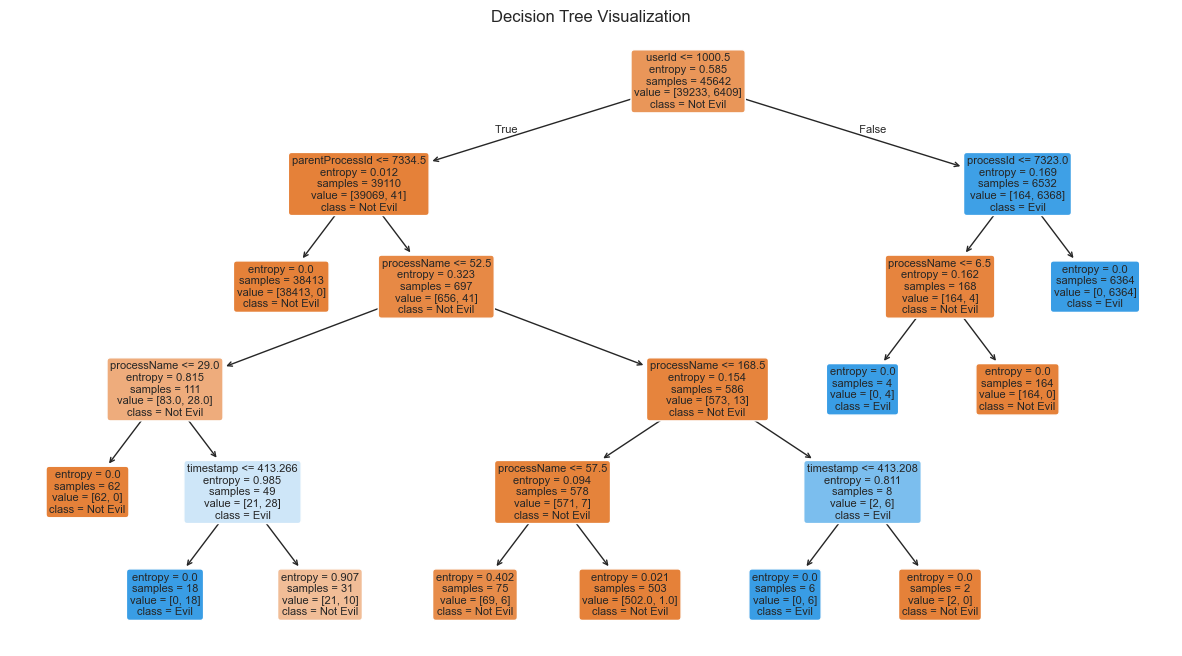


 RANDOM FOREST RESULTS 
Accuracy: 1.000
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      9809
           1       1.00      1.00      1.00      1602

    accuracy                           1.00     11411
   macro avg       1.00      1.00      1.00     11411
weighted avg       1.00      1.00      1.00     11411



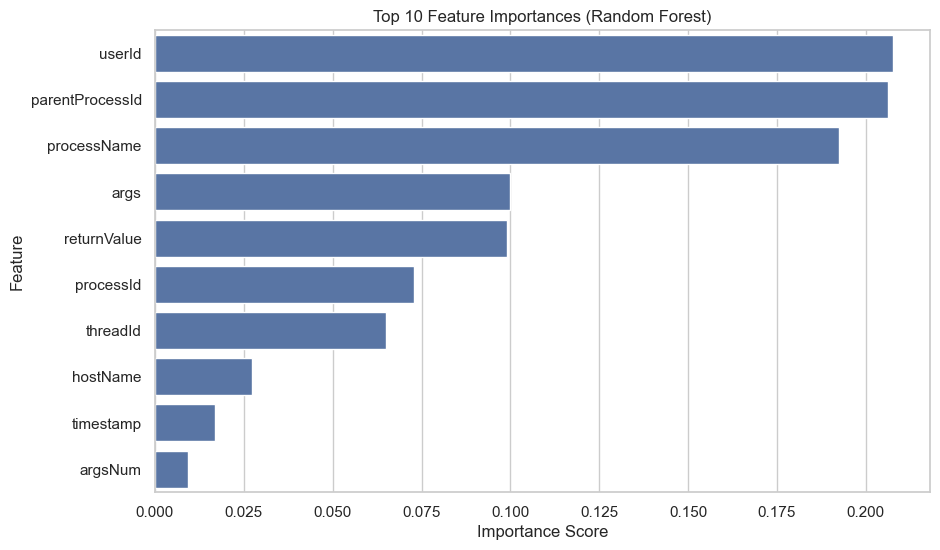


 Summary:
Decision Tree Accuracy: 0.999
Random Forest Accuracy: 1.000
 Random Forest generally performs better by reducing overfitting through feature randomization.


In [4]:
# =======================================================
#  Decision Tree & Random Forest (using adaptive sample)
# ============================================================

# Split features and target from adaptive sample
X = df_beth_sample.drop(['evil', 'sus'], axis=1, errors='ignore')
y = df_beth_sample['evil']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

# -------------------- Decision Tree --------------------
dt_model = DecisionTreeClassifier(
    criterion='entropy', 
    max_depth=5, 
    random_state=42
)
dt_model.fit(X_train, y_train)
y_pred_dt = dt_model.predict(X_test)

print("\n DECISION TREE RESULTS ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(classification_report(y_test, y_pred_dt))

# Visualize the Decision Tree
plt.figure(figsize=(15, 8))
plot_tree(
    dt_model, 
    feature_names=X.columns, 
    class_names=['Not Evil', 'Evil'],
    filled=True, 
    rounded=True,
    fontsize=8
)
plt.title("Decision Tree Visualization")
plt.show()

# -------------------- Random Forest --------------------
rf_model = RandomForestClassifier(
    n_estimators=100, 
    max_depth=None, 
    random_state=42
)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("\n RANDOM FOREST RESULTS ")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

# Feature Importances
importances = pd.Series(rf_model.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances.head(10), y=importances.head(10).index)
plt.title("Top 10 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# ============================================================
# Summary
# ============================================================

print("\n Summary:")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(" Random Forest generally performs better by reducing overfitting through feature randomization.")


### Conclusion
The Decision Tree and Random Forest models achieved near-perfect accuracy in classifying malicious (evil) and benign events in the BETH adaptive sample dataset.
Among all features, userId, parentProcessId, and processName emerged as the most influential predictors, followed by args and returnValue. These attributes reflect user behavior, process hierarchy, and command execution details key indicators for identifying potential security threats
the Decision Tree provided interpretability and clear decision rules, the Random Forest model offered superior generalization by reducing overfitting through ensemble learning. This makes it the preferred model for practical applications such as automated intrusion detection or anomaly monitoring.

Overall, this analysis confirms that machine learning—especially ensemble methods like Random Forest can effectively detect and classify malicious activity in system logs, offering valuable insights for proactive cybersecurity defense.

## Dataset 2: Cybersecurity dataset
#### (i) Exploratory Data analysis

In [5]:


# Drop unnecessary columns
cols_to_dropcsa = ['Source IP Address','Destination IP Address','User Information', 
                    'Device Information','Geo-location Data','Proxy Information',
                    'Log Source','Payload Data']
df_new_csa = df_csa.drop(columns=cols_to_dropcsa)

# Fill missing values
df_new_csa['Malware Indicators'] = df_new_csa['Malware Indicators'].fillna('None Detected')
df_new_csa['Alerts/Warnings'] = df_new_csa['Alerts/Warnings'].fillna('No Alert')


# Encode categorical columns
csa_categorical_columns = [ 'Protocol', 'Packet Type', 'Traffic Type', 'Malware Indicators', 
                            'Alerts/Warnings', 'Attack Type', 'Attack Signature', 'Action Taken', 
                            'Severity Level', 'Network Segment', 'Firewall Logs', 'IDS/IPS Alerts']

df_csa_encoded = df_new_csa.copy()
df_csa_encoded['Timestamp'] = pd.to_datetime(df_csa_encoded['Timestamp'], errors='coerce')
df_csa_encoded = df_csa_encoded.dropna(subset=['Timestamp'])  # Drop rows with invalid timestamps

# Extract time features
df_csa_encoded['Hour'] = df_csa_encoded['Timestamp'].dt.hour
df_csa_encoded['Weekday'] = df_csa_encoded['Timestamp'].dt.weekday
df_csa_encoded['Month'] = df_csa_encoded['Timestamp'].dt.month

# Label encode categorical features
from sklearn.preprocessing import LabelEncoder

label_encoders = {}
for col in csa_categorical_columns:
    le = LabelEncoder()
    df_csa_encoded[col] = le.fit_transform(df_csa_encoded[col].astype(str))
    label_encoders[col] = le

# Combine numeric and encoded features
df_features = df_csa_encoded.select_dtypes(include='number').fillna(0)

# Split features and target
X_csa = df_features.drop(columns=['Anomaly Scores'])
y_csa = df_features['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
 
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(X_csa, y_csa_bin, test_size=0.2, random_state=0)
 
 
 

###############################################################Regularize features #################################3
reg_csa = StandardScaler()
X_train_csa_reg = reg_csa.fit_transform(X_train_csa)
X_test_csa_reg= reg_csa.transform(X_test_csa)

X_train_csa_df = pd.DataFrame(X_train_csa, columns=X_train_csa.columns)
X_train_csa_reg_df = pd.DataFrame(X_train_csa_reg, columns=X_train_csa.columns)
X_test_csa_df = pd.DataFrame(X_test_csa, columns=X_test_csa.columns)
X_test_csa_reg_df = pd.DataFrame(X_test_csa_reg, columns=X_test_csa.columns)

######################################################## Normalize features#############################################333333333
    # Bormalize the features
norm_csa = MinMaxScaler()
X_train_norm_csa = norm_csa.fit_transform(X_train_csa)
X_test_norm_csa = norm_csa.transform(X_test_csa)

# Convert scaled features back to DataFrames
X_train_csa_df=pd.DataFrame(X_train_csa,columns=X_train_csa.columns)
X_train_norm_csa_df = pd.DataFrame(X_train_norm_csa, columns=X_train_csa.columns)
X_test_csa_df=pd.DataFrame(X_test_csa,columns=X_test_csa.columns)
X_test_norm_csa_df = pd.DataFrame(X_test_norm_csa, columns=X_train_csa.columns)



#  Decision trees and random forest

✅ Adaptive sample size selected: 2000 rows from 40000 total

🌳 DECISION TREE RESULTS (CSA)
Accuracy: 0.995
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      1.00      1.00       398

    accuracy                           0.99       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.99      0.99      0.99       400



c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

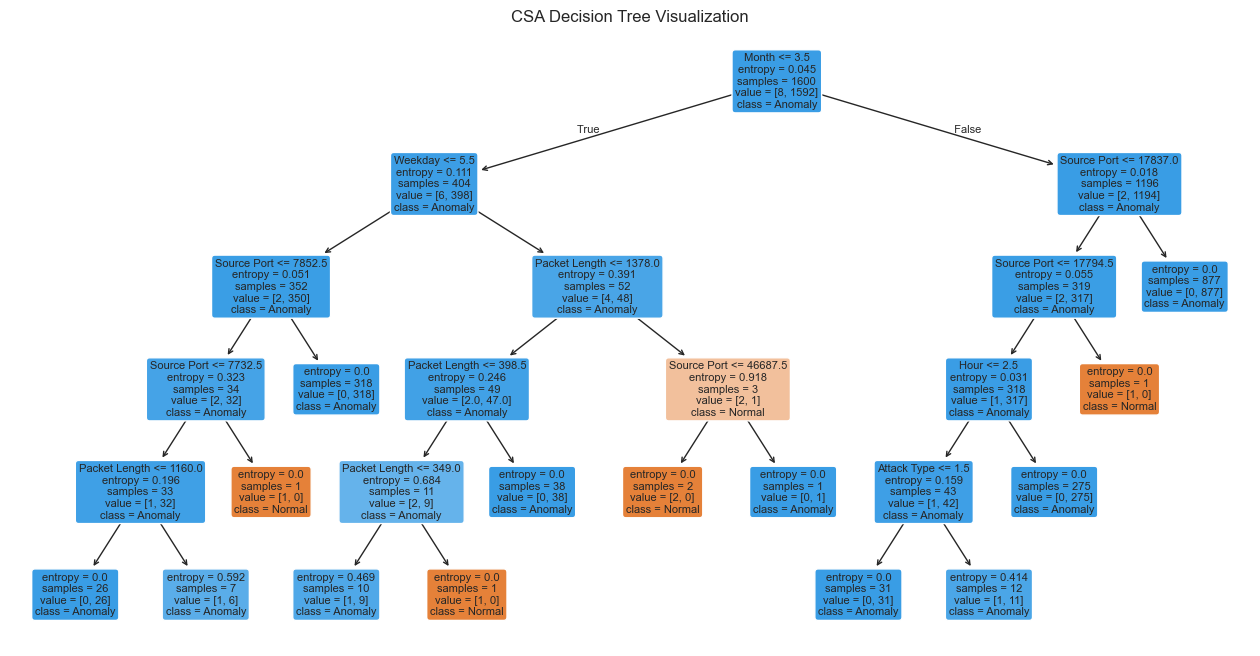


🌲 RANDOM FOREST RESULTS (CSA)
Accuracy: 0.995
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         2
           1       0.99      1.00      1.00       398

    accuracy                           0.99       400
   macro avg       0.50      0.50      0.50       400
weighted avg       0.99      0.99      0.99       400



c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\phxlab\AppData\Local\Programs\Python\Python312\Lib\site-packages\sklearn\metrics\_classification.py:1706: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(

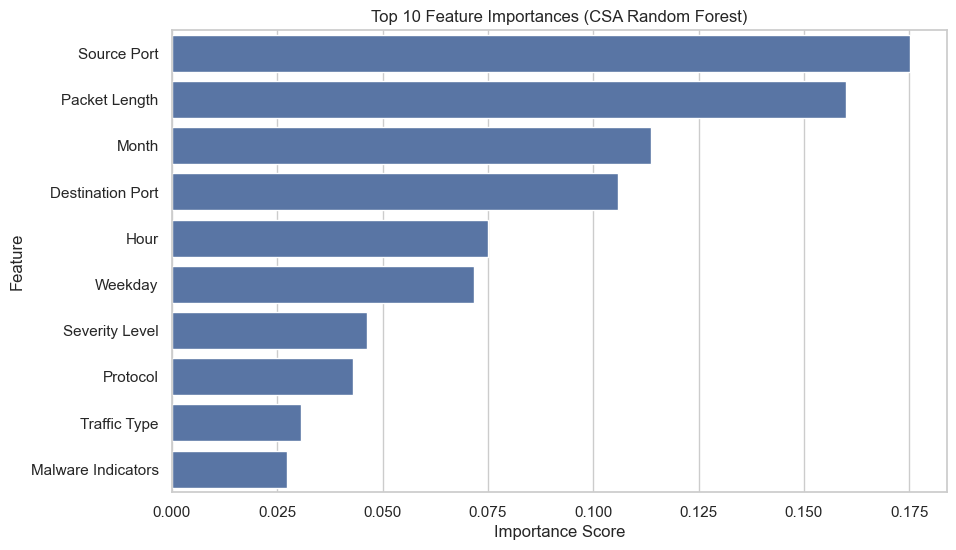


📊 Summary (CSA Adaptive Sample):
Decision Tree Accuracy: 0.995
Random Forest Accuracy: 0.995
✅ Random Forest typically outperforms Decision Tree due to ensemble averaging and reduced overfitting.


In [6]:
# =======================================================
#  Decision Tree & Random Forest (CSA Dataset — Adaptive Sample)
# =======================================================

# 1️⃣ Adaptive Sampling
total_rows_csa = df_csa_encoded.shape[0]

# If large dataset (>20k rows), take 5%; else take up to 1000 rows
if total_rows_csa > 20000:
    sample_size_csa = int(total_rows_csa * 0.05)
else:
    sample_size_csa = min(1000, total_rows_csa)

df_csa_sample = df_csa_encoded.sample(n=sample_size_csa, random_state=42)
print(f"✅ Adaptive sample size selected: {sample_size_csa} rows from {total_rows_csa} total")

# 2️⃣ Split features and target
X_csa = df_csa_sample.drop(columns=['Anomaly Scores','Timestamp'], errors='ignore')
y_csa = df_csa_sample['Anomaly Scores']

# Convert continuous anomaly scores to binary (0/1)
threshold = 0.5
y_csa_bin = (y_csa > threshold).astype(int)

# Train/test split
X_train_csa, X_test_csa, y_train_csa, y_test_csa = train_test_split(
    X_csa, y_csa_bin, test_size=0.2, random_state=42, stratify=y_csa_bin
)

# =======================================================
#  Decision Tree Classifier (Entropy Criterion)
# =======================================================
dt_csa = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    random_state=42
)
dt_csa.fit(X_train_csa, y_train_csa)
y_pred_dt_csa = dt_csa.predict(X_test_csa)

print("\n🌳 DECISION TREE RESULTS (CSA)")
print(f"Accuracy: {accuracy_score(y_test_csa, y_pred_dt_csa):.3f}")
print(classification_report(y_test_csa, y_pred_dt_csa))

# Visualize Decision Tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt_csa,
    feature_names=X_csa.columns,
    class_names=['Normal', 'Anomaly'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("CSA Decision Tree Visualization")
plt.show()

# =======================================================
#  Random Forest Classifier (Hyperparameter exploration)
# =======================================================
rf_csa = RandomForestClassifier(
    n_estimators=150,
    criterion='entropy',
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42
)
rf_csa.fit(X_train_csa, y_train_csa)
y_pred_rf_csa = rf_csa.predict(X_test_csa)

print("\n🌲 RANDOM FOREST RESULTS (CSA)")
print(f"Accuracy: {accuracy_score(y_test_csa, y_pred_rf_csa):.3f}")
print(classification_report(y_test_csa, y_pred_rf_csa))

# Feature Importances
importances_csa = pd.Series(rf_csa.feature_importances_, index=X_csa.columns).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=importances_csa.head(10), y=importances_csa.head(10).index)
plt.title("Top 10 Feature Importances (CSA Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# =======================================================
#  Summary
# =======================================================
print("\n📊 Summary (CSA Adaptive Sample):")
print(f"Decision Tree Accuracy: {accuracy_score(y_test_csa, y_pred_dt_csa):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test_csa, y_pred_rf_csa):.3f}")
print("✅ Random Forest typically outperforms Decision Tree due to ensemble averaging and reduced overfitting.")


## Dataset 3: UNSW - dataset
#### (i) Exploratory Data analysis 

In [9]:
# DATASET 3 : UNSW-NB15 Intrusion Detection Dataset
path = kagglehub.dataset_download("dhoogla/unswnb15")
df_unsw= pd.read_parquet(os.path.join(path, 'UNSW_NB15_training-set.parquet'))
df_test_unsw=pd.read_parquet(os.path.join(path, 'UNSW_NB15_testing-set.parquet'))

unsw_numeric_columns=df_unsw.select_dtypes(include='number').columns

unsw_categorical_columns=df_unsw.select_dtypes(include=['object', 'category']).columns

# Combine training and test sets for preprocessing
df_unsw_combined = pd.concat([df_unsw, df_test_unsw], axis=0, ignore_index=True)

# Encode categorical columns
 
label_encoders = {}
for col in unsw_categorical_columns:
    le = LabelEncoder()
    df_unsw_combined[col] = le.fit_transform(df_unsw_combined[col].astype(str).fillna('Unknown'))
    label_encoders[col] = le

# Features and target (using 'lAabel' as the target variable)
X = df_unsw_combined[unsw_numeric_columns.tolist() + unsw_categorical_columns.tolist()].drop(columns=['label'])
y = df_unsw_combined['label']

#####################################################################Split into train and test sets
 
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)


unsw_numeric=df_unsw_combined.select_dtypes(include='number').columns
print("Numeric columns in the dataset:\n")
print(unsw_numeric_columns)
print('\n')

unsw_categorical=df_unsw_combined.select_dtypes(include='object').columns
print("Categorical columns in the dataset:\n")
print(unsw_categorical_columns)
####################################################Regularize ##########################################################

reg_unsw = StandardScaler()
X_train_unsw_reg= reg_unsw.fit_transform(X_train)
X_test_unsw_reg = reg_unsw.transform(X_test)

X_train_unsw_df = pd.DataFrame(X_train, columns=X_train.columns)
X_train_unsw_reg_df = pd.DataFrame(X_train_unsw_reg, columns=X_train.columns)
X_test_unsw_df = pd.DataFrame(X_test, columns=X_test.columns)
X_test_unsw_reg_df = pd.DataFrame(X_test_unsw_reg, columns=X_test.columns)



##################### Normalize the features###################################################3
norm_unsw = MinMaxScaler()
X_train_norm_unsw = norm_unsw.fit_transform(X_train)
X_test_norm_unsw = norm_unsw.transform(X_test)

# Convert scaled features back to DataFrames
X_train_norm_unnsw_df = pd.DataFrame(X_train_norm_unsw, columns=X_train.columns)
X_test_norm_unsw_df = pd.DataFrame(X_test_norm_unsw, columns=X_train.columns)



Numeric columns in the dataset:

Index(['dur', 'spkts', 'dpkts', 'sbytes', 'dbytes', 'rate', 'sload', 'dload',
       'sloss', 'dloss', 'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb',
       'dtcpb', 'dwin', 'tcprtt', 'synack', 'ackdat', 'smean', 'dmean',
       'trans_depth', 'response_body_len', 'ct_src_dport_ltm',
       'ct_dst_sport_ltm', 'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd',
       'is_sm_ips_ports', 'label'],
      dtype='object')


Categorical columns in the dataset:

Index(['proto', 'service', 'state', 'attack_cat'], dtype='object')


#  Decision trees and random forest

✅ Adaptive sample size after dropping NaNs: 8268 rows from 206138 training rows

🌳 DECISION TREE RESULTS (UNSW-NB15)
Accuracy: 0.639
              precision    recall  f1-score   support

           0       0.57      0.01      0.03     18653
           1       0.64      0.99      0.78     32882

    accuracy                           0.64     51535
   macro avg       0.61      0.50      0.40     51535
weighted avg       0.62      0.64      0.51     51535



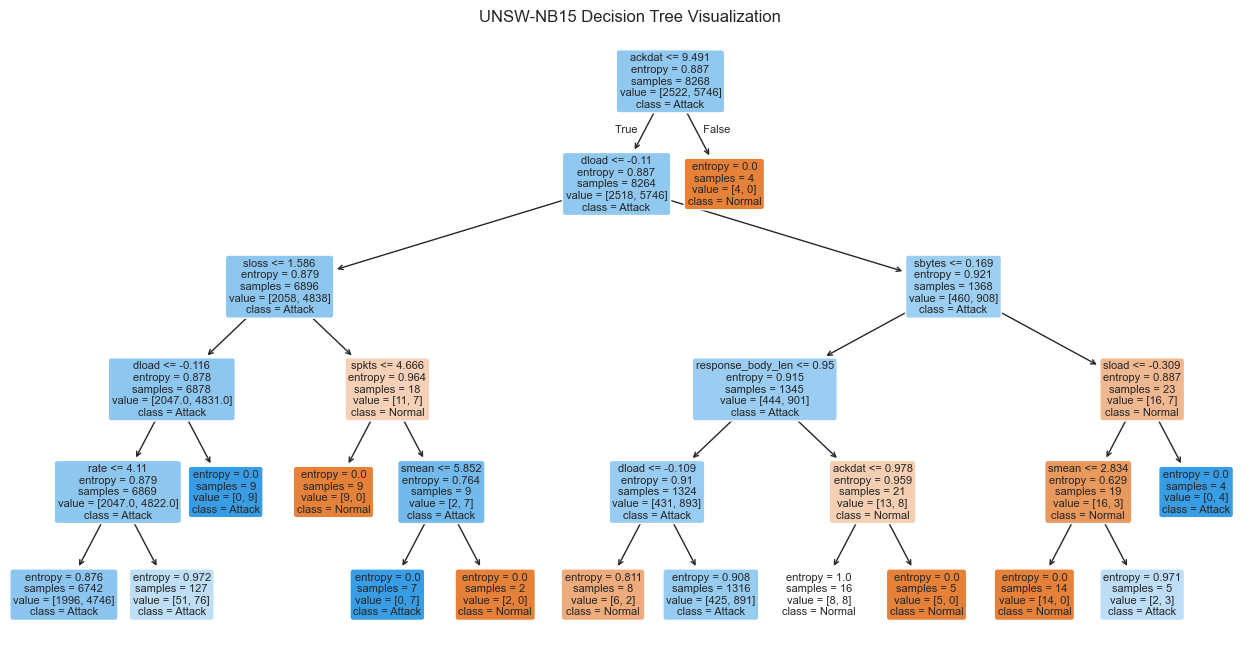


🌲 RANDOM FOREST RESULTS (UNSW-NB15)
Accuracy: 0.641
              precision    recall  f1-score   support

           0       0.52      0.10      0.16     18653
           1       0.65      0.95      0.77     32882

    accuracy                           0.64     51535
   macro avg       0.59      0.52      0.47     51535
weighted avg       0.60      0.64      0.55     51535



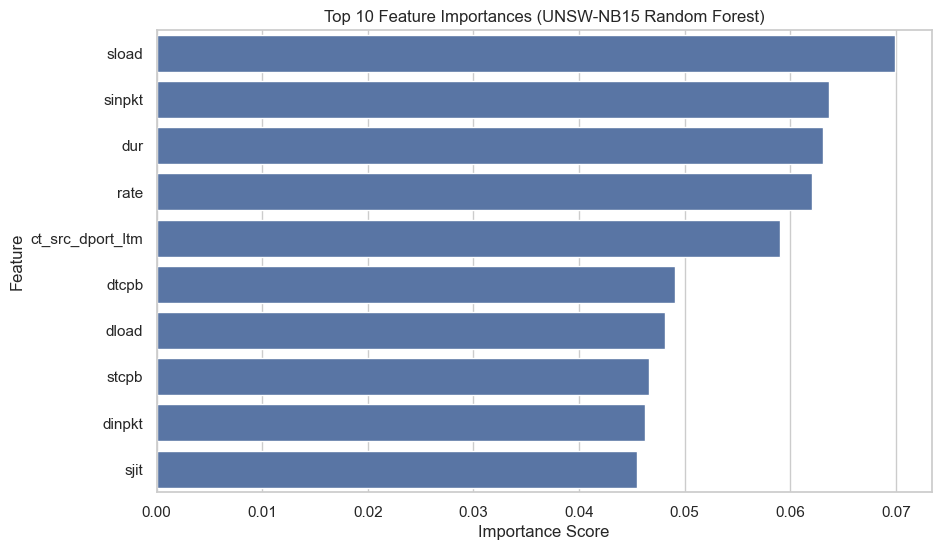


📊 Summary (UNSW-NB15 Adaptive Sample):
Decision Tree Accuracy: 0.639
Random Forest Accuracy: 0.641
✅ Random Forest usually performs better due to ensemble averaging and reduced overfitting.


In [14]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.impute import SimpleImputer

# =======================================================
#  Adaptive Sampling on Training Set with NaN handling
# =======================================================
total_rows_train = X_train_unsw_reg_df.shape[0]

# Determine sample size
if total_rows_train > 20000:
    sample_size_train = int(total_rows_train * 0.05)
else:
    sample_size_train = min(1000, total_rows_train)

# Sample training set
sampled = X_train_unsw_reg_df.join(y_train).sample(n=sample_size_train, random_state=42)
target_col = y_train.name

# Drop rows where target is NaN
sampled = sampled.dropna(subset=[target_col])

# Separate features and target
X_train_sample = sampled.drop(columns=target_col)
y_train_sample = sampled[target_col]

# Handle NaNs in features (if any) by replacing with median
imputer = SimpleImputer(strategy='median')
X_train_sample = pd.DataFrame(imputer.fit_transform(X_train_sample), columns=X_train_sample.columns)
X_test_clean = pd.DataFrame(imputer.transform(X_test_unsw_reg_df), columns=X_test_unsw_reg_df.columns)

print(f"✅ Adaptive sample size after dropping NaNs: {X_train_sample.shape[0]} rows from {total_rows_train} training rows")

# =======================================================
#  Decision Tree Classifier
# =======================================================
dt_unsw = DecisionTreeClassifier(criterion='entropy', max_depth=5, random_state=42)
dt_unsw.fit(X_train_sample, y_train_sample)
y_pred_dt = dt_unsw.predict(X_test_clean)

print("\n🌳 DECISION TREE RESULTS (UNSW-NB15)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(classification_report(y_test, y_pred_dt))

# Visualize Decision Tree
plt.figure(figsize=(16, 8))
plot_tree(
    dt_unsw,
    feature_names=X_train_sample.columns,
    class_names=['Normal', 'Attack'],
    filled=True,
    rounded=True,
    fontsize=8
)
plt.title("UNSW-NB15 Decision Tree Visualization")
plt.show()

# =======================================================
#  Random Forest Classifier
# =======================================================
rf_unsw = RandomForestClassifier(
    n_estimators=150,
    criterion='entropy',
    max_depth=None,
    min_samples_split=4,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)
rf_unsw.fit(X_train_sample, y_train_sample)
y_pred_rf = rf_unsw.predict(X_test_clean)

print("\n🌲 RANDOM FOREST RESULTS (UNSW-NB15)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print(classification_report(y_test, y_pred_rf))

# Feature Importances
importances_rf = pd.Series(rf_unsw.feature_importances_, index=X_train_sample.columns).sort_values(ascending=False)
plt.figure(figsize=(10, 6))
sns.barplot(x=importances_rf.head(10), y=importances_rf.head(10).index)
plt.title("Top 10 Feature Importances (UNSW-NB15 Random Forest)")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.show()

# =======================================================
#  Summary
# =======================================================
print("\n📊 Summary (UNSW-NB15 Adaptive Sample):")
print(f"Decision Tree Accuracy: {accuracy_score(y_test, y_pred_dt):.3f}")
print(f"Random Forest Accuracy: {accuracy_score(y_test, y_pred_rf):.3f}")
print("✅ Random Forest usually performs better due to ensemble averaging and reduced overfitting.")
